# Predicting Startup Profit using Multiple Linear Regression

Objective:
The primary goal of this task is to develop a multiple linear regression model that accurately predicts the Profit
of a startup based on its expenditures in various areas and its operating state.
The developed model will then be used to forecast profits for unseen data.

Dataset:
The dataset to be used is located at:
Machine-Learning-A-Z-Codes-Datasets\Machine-Learning-A-Z-Codes-Datasets\Part 2 - Regression\Section 5 - Multiple Linear Regression\Python\50_Startups.csv

Data Description:
The dataset contains information on 50 different startups, including:

R&D Spend: Expenditure on Research and Development.

Administration: Expenditure on administrative overhead.

Marketing Spend: Expenditure on marketing activities.

State: The geographical state where the startup operates (categorical).

Profit: The dependent variable, representing the total profit generated by the startup.

Task Steps:

Data Loading and initial data exploration:

Feature Engineering and Preprocessing: Identify the independent variables (features) and
the dependent variable (target).

Handling Categorical Data: tailoring the categorical data for regression modelling

Data Splitting and model training

Model Evaluation

Discussion on the meaning of the coefficients in the fitted model in the context of the business problem

Evaluate the correlation coefficients and P values between features and their business meanings

## Importing the libraries

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests

## Dawnloading and reading the csv file

In [18]:
url = "https://raw.githubusercontent.com/farhanchoudhary/Machine_Learning_A-Z_All_Codes_and_Templates/refs/heads/master/3.%20Multiple%20Linear%20Regression/50_Startups.csv"

r = requests.get(url)
with open("50_Startups.csv", "wb") as f:
  f.write(r.content)

df = pd.read_csv("50_Startups.csv")
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [19]:
# we need to get an insight about the generalities of the data, number of rows
# number of columns, null values and column types of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [20]:
# then a brief statistical status of different columns are evaluated
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [21]:
# Sepatation of the feature from target columns
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values


## Encoding categorical data

In [22]:
# to use this dataset in a linear regression model, we need to replace the categorical data with
# One Hot encoder

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(drop = "first"), [3])], remainder = 'passthrough')
X = ct.fit_transform(X)
print(X[0:5, :])

# ‘encoder’ is the name of the transformer
# OneHotEncoder is an instance of OneHotEncoder class for binary classification
# [3] is the index of the categorical column we want to transform to OneHot format
# remainder = ‘passthrough’ keeps all the other columns in the dataset without making any changes on them
# The default value for remainder is 'drop', meaning that the numeric columns are dropped after transformation

[[0.0 1.0 165349.2 136897.8 471784.1]
 [0.0 0.0 162597.7 151377.59 443898.53]
 [1.0 0.0 153441.51 101145.55 407934.54]
 [0.0 1.0 144372.41 118671.85 383199.62]
 [1.0 0.0 142107.34 91391.77 366168.42]]


From comparison of the encoded categorical columns with the original column of the data, it turns out that the first column (removed) belongs to California, second to Florida and third to New York. Now, only two dummy columns remain in the final X. first columns shows Florida and the second shows New York city.

## Splitting the dataset into the Training set and Test set

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Training the Multiple Linear Regression model on the Training set

In [24]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(X_train, y_train)

LinearRegression()

## Predicting the Test set results

Text(0, 0.5, 'predicted data')

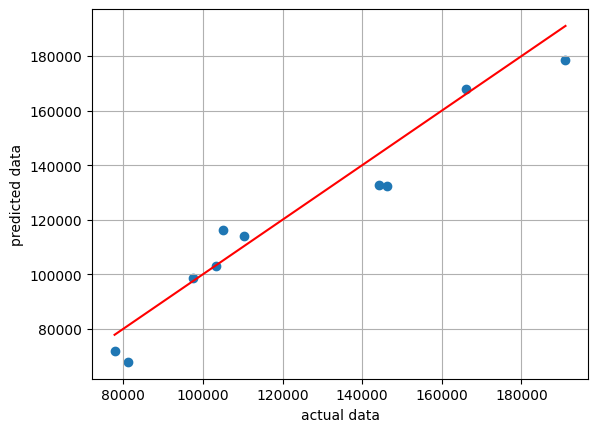

In [25]:
# the test features are used as representatives of unseen data in the model and the
# deviations of the predicted target values are compared with the real target values
# in the test set

y_predict = LR.predict(X_test)

plt.scatter(y_test, y_predict)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'r')
plt.grid()
plt.xlabel('actual data')
plt.ylabel('predicted data')

In [26]:
# Different Error Calculations

from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
R_2 = r2_score(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)
RMSE = root_mean_squared_error(y_test, y_predict)

print('R squared error :', R_2)
print('Mean absolute error :', MAE)
print('Root mean squared error :', RMSE)

R squared error : 0.9347068473282987
Mean absolute error : 7514.293659636814
Root mean squared error : 9137.990152791011


R-squared error tells us what proportion of target value variations could be explained by the presented features. For example, here, this proportion is 93%.

The difference between the MAE and RMSE parameters is indicative of the presence of the outliers in the data. The closer these two error metrics to each other, the fewer the number of the outliers.

## Coefficients and interception


In [27]:
# We can also find the coefficients of the multiple linear regression model.
# the first two numbers are related to the dummy variable representing the states
print(f'Coefficients: {LR.coef_}')

# The intercept is separately calculated and shows the effect of the removed dummy variabl
# California under the condition that all other variables were zero.

print(f'Intercept: {LR.intercept_}')

Coefficients: [-9.59284160e+02  6.99369053e+02  7.73467193e-01  3.28845975e-02
  3.66100259e-02]
Intercept: 42554.167617767


The important point about the coeffiecients above is that
if all other feature were zero, the amount of profit predicted by California state (the intercept) would be 42554.167.


To see the amount of prediction by Florida, we should consider the intercept + first element of the coefficients, i.e., 42554.167 + 959.284

Similarly, the predicted amount by New York is 42554.167 + 699.369



## Correlation and P value

In [28]:
# we can also calculate the p value and correlation coefficients between feature pairs.
# the most important thing here for us the correlation between the profit (target) and
# other numeric columns (we do not consider the dummy variable columns)
# Considering a certain value of the significance level (SL) the low P values states
# there is a large chance that the pairs of features are strongly
# correlated (we reject the null hypothesis stating there is no correlation, or if there is
# a correlation, it is only by chance)

from scipy.stats import pearsonr
columns = df.iloc[:, [0, 1, 2, 4]].columns
print(columns)

dictionary = {}

for col1 in columns:
  for col2 in columns:
    corr, p_value = pearsonr(df[col1], df[col2])
    dictionary[f'{col1} & {col2}'] = (corr, p_value)

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit'], dtype='object')


In [29]:
corr_PValue = pd.DataFrame(dictionary)
corr_PValue.reset_index(drop = True, inplace = True)
CP = corr_PValue.T

In [30]:
CP.columns = ['correlation', 'p-value']
CP

,correlation,p-value
R&D Spend & R&D Spend,1.000000,0.000000e+00
R&D Spend & Administration,0.241955,9.048123e-02
R&D Spend & Marketing Spend,0.724248,2.769808e-09
R&D Spend & Profit,0.972900,3.500322e-32
Administration & R&D Spend,0.241955,9.048123e-02
Administration & Administration,1.000000,0.000000e+00
Administration & Marketing Spend,-0.032154,8.245717e-01
Administration & Profit,0.200717,1.622174e-01
Marketing Spend & R&D Spend,0.724248,2.769808e-09
Marketing Spend & Administration,-0.032154,8.245717e-01
